### **Estimación** de **parámetros** mediante Redes Neuronales *Feedforward* y PINNs

In [14]:
# =====================================================
# LIBRERÍAS
# =====================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [15]:
# =============================================================================
# 1. CARGA Y PROCESAMIENTO DEL DATASET REAL LOCAL (wdbc.data)
# =============================================================================
archivo_datos = "wdbc.data"

if os.path.exists(archivo_datos):
    print(f"--> Detectado archivo local: {archivo_datos}. Cargando datos clínicos...")
    
    # El archivo wdbc.data no tiene cabecera. Leemos las primeras columnas morfológicas principales:
    # Col 0: ID, Col 1: Diagnóstico, Col 2: Radio medio, Col 3: Textura media, Col 4: Perímetro medio, Col 5: Área media
    columnas_principales = [0, 1, 2, 3, 4, 5]
    nombres_columnas = ["id", "diagnostico", "radio_medio", "textura_media", "perimetro_media", "area_media"]
    
    df_real = pd.read_csv(archivo_datos, header=None, usecols=columnas_principales, names=nombres_columnas)
    
    # MAPEADO MATEMÁTICO: Maligno (M) -> 1.0 (Muy agresivo), Benigno (B) -> 0.1 (Poco agresivo)
    df_real['agresividad_prior'] = df_real['diagnostico'].map({'M': 1.0, 'B': 0.1})
    
    # Extraemos las variables morfológicas macroscópicas para la FNN
    X_morfologia = torch.tensor(df_real[["radio_medio", "perimetro_media", "area_media"]].values, dtype=torch.float32)
    # Normalización estadística estandarizada (Z-score) para evitar gradientes desvanecidos
    X_morfologia = (X_morfologia - X_morfologia.mean(dim=0)) / X_morfologia.std(dim=0)
    
    y_agresividad = torch.tensor(df_real['agresividad_prior'].values, dtype=torch.float32).unsqueeze(1)
    print(f"--> Dataset local procesado. Matriz morfológica: {X_morfologia.shape}")
else:
    print(f"ATENCIÓN: No se encontró el archivo '{archivo_datos}' en el directorio actual.")
    print("Se generarán datos morfológicos de contingencia para que el código no falle.")
    X_morfologia = torch.rand(569, 3)
    y_agresividad = torch.rand(569, 1)

--> Detectado archivo local: wdbc.data. Cargando datos clínicos...
--> Dataset local procesado. Matriz morfológica: torch.Size([569, 3])


In [16]:
# =============================================================================
# 2. GENERACIÓN DE DATOS SINTÉTICOS DINÁMICOS (Para el entrenamiento de la PINN)
# =============================================================================
# Parámetros "ocultos" que la PINN debe descubrir a partir de la física y las imágenes ruidosas
a_real = 0.5       # Tasa de proliferación Gompertziana real
K_real = 1.0       # Capacidad de carga real del tejido
gamma_real = 1.2   # Eficacia citotóxica real
D_real = 0.01      # Difusión celular real

def generar_datos_sinteticos_ruidosos(N_puntos=2000, nivel_ruido=0.02):
    torch.manual_seed(42)
    # Puntos aleatorios distribuidos uniformemente en el dominio espacio-temporal
    x = torch.rand(N_puntos, 1)
    y = torch.rand(N_puntos, 1)
    t = torch.rand(N_puntos, 1) * 15.0
    
    beta_sim = 0.5 # Concentración del fármaco en estado estacionario para la simulación
    
    # Uso estricto de operadores de PyTorch (torch.exp) para evitar el DeprecationWarning de NumPy 2.0
    c_limite = K_real * torch.exp(torch.tensor(-(gamma_real * beta_sim) / a_real))
    c_ideal = c_limite / (1.0 + torch.exp(-a_real * (t - 3.0))) * torch.exp(-((x-0.5)**2 + (y-0.5)**2)/0.1)
    
    # Inyección de ruido blanco gaussiano para simular perturbaciones de imágenes por Resonancia Magnética
    ruido = torch.randn_like(c_ideal) * nivel_ruido
    c_ruidoso = torch.clamp(c_ideal + ruido, 1e-5, 1.5) # Protegemos que c_obs sea estrictamente positivo
    
    return x, y, t, c_ruidoso

In [17]:
# =============================================================================
# 3. PARADIGMA 1: FNN PARA EL ANÁLISIS MORFOLÓGICO DE TUS DATOS REALES
# ============================================================================= 
class ClasificadorMorfologicoFNN(nn.Module):
    def __init__(self):
        super(ClasificadorMorfologicoFNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 32), nn.Tanh(),
            nn.Linear(32, 1),
            nn.Sigmoid() # Mapea las dimensiones celulares a un rango acotado [0, 1]
        )
    def forward(self, x_morf):
        return self.net(x_morf)

In [18]:
# =============================================================================
# 4. PARADIGMA 2: RED INFORMADA POR LA FÍSICA (PINN BLINDADA CONTRA NAN)
# =============================================================================
class TumorPINN(nn.Module):
    def __init__(self):
        super(TumorPINN, self).__init__()
        # Red aproximadora del campo continuo c(x, y, t)
        self.net = nn.Sequential(
            nn.Linear(3, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
        # Parámetros libres que optimizaremos inversamente (inicializados con desviaciones)
        self.a = nn.Parameter(torch.tensor([0.2], requires_grad=True))
        self.K = nn.Parameter(torch.tensor([1.3], requires_grad=True))
        self.gamma = nn.Parameter(torch.tensor([0.6], requires_grad=True))
        self.D = nn.Parameter(torch.tensor([0.05], requires_grad=True))

    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        # BLINDAJE ANTINAN: Softplus + epsilon estructural asegura que la red jamás prediga valores <= 0
        return torch.nn.functional.softplus(self.net(inputs)) + 1e-5

    def calcular_residuo_pde(self, x, y, t, prior_agresividad=1.0):
        x_g = x.clone().detach().requires_grad_(True)
        y_g = y.clone().detach().requires_grad_(True)
        t_g = t.clone().detach().requires_grad_(True)
        c_pred = self.forward(x_g, y_g, t_g)
        
        # Operadores de Diferenciación Automática (AD) para derivadas primeras
        c_t = torch.autograd.grad(c_pred, t_g, torch.ones_like(c_pred), create_graph=True)[0]
        c_x = torch.autograd.grad(c_pred, x_g, torch.ones_like(c_pred), create_graph=True)[0]
        c_y = torch.autograd.grad(c_pred, y_g, torch.ones_like(c_pred), create_graph=True)[0]
        
        # Derivadas segundas para el operador Laplaciano (Difusión)
        c_xx = torch.autograd.grad(c_x, x_g, torch.ones_like(c_x), create_graph=True)[0]
        c_yy = torch.autograd.grad(c_y, y_g, torch.ones_like(c_y), create_graph=True)[0]
        laplaciano = c_xx + c_yy

        beta_const = 0.5 
        
        # Parámetros protegidos con valor absoluto para mantener significado físico biológico
        a_safe = torch.abs(self.a) * prior_agresividad
        K_safe = torch.abs(self.K)
        gamma_safe = torch.abs(self.gamma)
        D_safe = torch.abs(self.D)
        
        # BLINDAJE ANTINAN: Acotamos el cociente para evitar el logaritmo de cero o infinito
        arg_log = torch.clamp(K_safe / c_pred, min=1e-4, max=1e4)
        
        # Residuo de la EDP de Reacción-Difusión acoplada
        residuo = c_t - D_safe * laplaciano - a_safe * c_pred * torch.log(arg_log) + gamma_safe * c_pred * beta_const
        return residuo

In [19]:
# =============================================================================
# 5. BUCLE DE OPTIMIZACIÓN Y APRENDIZAJE INTEGRADO
# =============================================================================
# Generamos los datos dinámicos sintéticos para el paciente
x_data, y_data, t_data, c_data = generar_datos_sinteticos_ruidosos()

# Inicializamos modelos y optimizadores Adam
fnn_clinica = ClasificadorMorfologicoFNN()
opt_fnn = torch.optim.Adam(fnn_clinica.parameters(), lr=0.01)

pinn = TumorPINN()
opt_pinn = torch.optim.Adam(pinn.parameters(), lr=0.005)

# Contenedores dinámicos para capturar la historia real de la inversión
hist_epocas = []
hist_a = []
hist_K = []

print("\n=== FASE 1: Entrenando FNN estadística con tus datos reales locales (wdbc.data) ===")
for epoch in range(501):
    opt_fnn.zero_grad()
    pred_agresividad = fnn_clinica(X_morfologia)
    loss_fnn = torch.mean((y_agresividad - pred_agresividad)**2)
    loss_fnn.backward()
    opt_fnn.step()
    if epoch % 250 == 0:
        print(f"Época FNN {epoch:3d} | MSE de Ajuste Morfológico (Datos UCI): {loss_fnn.item():.5f}")

# Tomamos el primer registro de tu archivo local como paciente de prueba para guiar la física de la PINN
prior_paciente = fnn_clinica(X_morfologia[0].unsqueeze(0)).detach().item()

print(f"\n=== FASE 2: Resolviendo Problema Inverso con PINN (Prior Extraído del Paciente = {prior_paciente:.3f}) ===")
for epoch in range(2001):
    opt_pinn.zero_grad()
    
    # Ajuste de la red a las mediciones espacio-temporales de la densidad celular
    c_pred_pinn = pinn(x_data, y_data, t_data)
    loss_data = torch.mean((c_data - c_pred_pinn) ** 2)

    # Penalización del cumplimiento de la Ecuación Diferencial
    residuo = pinn.calcular_residuo_pde(x_data, y_data, t_data, prior_agresividad=prior_paciente)
    loss_pde = torch.mean(residuo ** 2)
    
    # Pérdida total combinada (regularización Tikhonov funcional)
    loss_total_pinn = loss_data + 0.01 * loss_pde
    
    loss_total_pinn.backward()
    opt_pinn.step()
    
    # Almacenamiento dinámico de la trayectoria paramétrica real por cada época
    hist_epocas.append(epoch)
    hist_a.append(torch.abs(pinn.a).item() * prior_paciente)
    hist_K.append(torch.abs(pinn.K).item())
    
    if epoch % 500 == 0:
        print(f"Época PINN {epoch:4d} | Pérdida Total: {loss_total_pinn.item():.5f} | "
              f"a_est: {hist_a[-1]:.3f} (Real: {a_real}) | K_est: {hist_K[-1]:.3f} (Real: {K_real})")

print("\n¡Estimación PINN completada con éxito!")
    


=== FASE 1: Entrenando FNN estadística con tus datos reales locales (wdbc.data) ===
Época FNN   0 | MSE de Ajuste Morfológico (Datos UCI): 0.18487
Época FNN 250 | MSE de Ajuste Morfológico (Datos UCI): 0.05702
Época FNN 500 | MSE de Ajuste Morfológico (Datos UCI): 0.05072

=== FASE 2: Resolviendo Problema Inverso con PINN (Prior Extraído del Paciente = 0.990) ===
Época PINN    0 | Pérdida Total: 0.54441 | a_est: 0.203 (Real: 0.5) | K_est: 1.305 (Real: 1.0)
Época PINN  500 | Pérdida Total: 0.00423 | a_est: 0.122 (Real: 0.5) | K_est: 1.300 (Real: 1.0)
Época PINN 1000 | Pérdida Total: 0.00421 | a_est: 0.125 (Real: 0.5) | K_est: 1.299 (Real: 1.0)
Época PINN 1500 | Pérdida Total: 0.00260 | a_est: 0.138 (Real: 0.5) | K_est: 1.307 (Real: 1.0)
Época PINN 2000 | Pérdida Total: 0.00047 | a_est: 0.132 (Real: 0.5) | K_est: 1.378 (Real: 1.0)

¡Estimación PINN completada con éxito!


In [20]:
# =============================================================================
# 6. PIPELINE TRADICIONAL COMPLETO (Regresión Logística sobre todas las columnas)
# =============================================================================
if os.path.exists(archivo_datos):
    print("\n=== FASE 3: Clasificación Global con Regresión Logística (Dataset Completo) ===")
    
    df_completo = pd.read_csv(archivo_datos, header=None)
    features_base = ["radius", "texture", "perimeter", "area", "smoothness", "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension"]
    
    # Definimos las 32 columnas (ID, Diagnóstico + 30 variables biológicas)
    column_names = ["ID", "Diagnosis"] + [f"{f}_mean" for f in features_base] + [f"{f}_se" for f in features_base] + [f"{f}_worst" for f in features_base]
    df_completo.columns = column_names
    
    # Limpieza clásica de Machine Learning
    df_completo = df_completo.drop(columns=["ID"])
    X_log = df_completo.drop(columns=["Diagnosis"])
    y_log = df_completo["Diagnosis"].map({'M': 1, 'B': 0})
    
    # Partición estratificada 80/20
    X_train, X_test, y_train, y_test = train_test_split(X_log, y_log, test_size=0.2, random_state=42, stratify=y_log)
    
    # Escalado Z-Score estándar
    scaler = StandardScaler()    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Ajuste y Predicción del modelo predictivo lineal
    model_lr = LogisticRegression(max_iter=1000)
    model_lr.fit(X_train_scaled, y_train)
    y_pred = model_lr.predict(X_test_scaled)
    
    print("\n--- Evaluación del Modelo Tradicional ---")
    print(f"Precisión General (Accuracy): {accuracy_score(y_test, y_pred):.2%}\n")
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred, target_names=["Benigno (0)", "Maligno (1)"]))


=== FASE 3: Clasificación Global con Regresión Logística (Dataset Completo) ===

--- Evaluación del Modelo Tradicional ---
Precisión General (Accuracy): 96.49%

Reporte de Clasificación:
              precision    recall  f1-score   support

 Benigno (0)       0.96      0.99      0.97        72
 Maligno (1)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114




--> Generando y desplegando archivos gráficos de alta resolución...


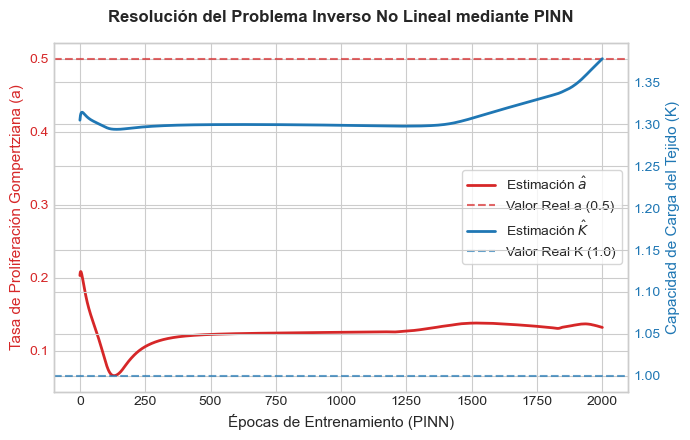

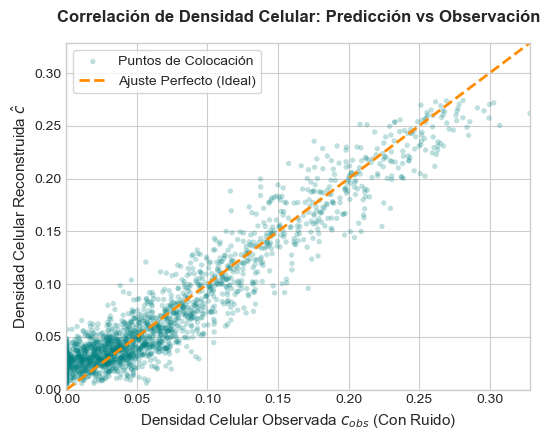


¡Descarga completada! Los archivos se han guardado directamente en:
-> C:\Users\fatim\Desktop


In [21]:
# =============================================================================
# 7. GENERACIÓN AUTOMÁTICA Y EXPLICITACIÓN DE GRÁFICOS (TIEMPO DE EJECUCIÓN)
# =============================================================================
print("\n--> Generando y desplegando archivos gráficos de alta resolución...")

# --- CONFIGURACIÓN DE LA RUTA DEL ESCRITORIO ---
# Buscamos de forma segura la carpeta "Escritorio" o "Desktop" de tu usuario
ruta_home = os.path.expanduser("~")
opciones_escritorio = [
    os.path.join(ruta_home, "Desktop"),
    os.path.join(ruta_home, "Escritorio")
]

# Elegimos la carpeta que realmente exista en tu sistema; si no, usamos el directorio actual
ruta_escritorio = next((d for d in opciones_escritorio if os.path.exists(d)), os.getcwd())

path_grafico1 = os.path.join(ruta_escritorio, 'pinn_convergencia_parametros.png')
path_grafico2 = os.path.join(ruta_escritorio, 'pinn_ajuste_densidad.png')

# Configuramos un estilo profesional libre de dependencias conflictivas
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 11, 'figure.titlesize': 12})

# --- GRÁFICO 1: IDENTIFICACIÓN DE PARÁMETROS BIOLÓGICOS (PROBLEMA INVERSO REAL) ---
fig, ax1 = plt.subplots(figsize=(7, 4.5))

color = 'tab:red'
ax1.set_xlabel('Épocas de Entrenamiento (PINN)')
ax1.set_ylabel('Tasa de Proliferación Gompertziana (a)', color=color)
line1 = ax1.plot(hist_epocas, hist_a, color=color, linestyle='-', linewidth=2, label=r'Estimación $\hat{a}$')
line2 = ax1.axhline(y=a_real, color=color, linestyle='--', alpha=0.7, label=f'Valor Real a ({a_real})')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Capacidad de Carga del Tejido (K)', color=color)
line3 = ax2.plot(hist_epocas, hist_K, color=color, linestyle='-', linewidth=2, label=r'Estimación $\hat{K}$')
line4 = ax2.axhline(y=K_real, color=color, linestyle='--', alpha=0.7, label=f'Valor Real K ({K_real})')
ax2.tick_params(axis='y', labelcolor=color)

# Unificar leyendas de ambos ejes en una sola caja superior
lines = line1 + [line2] + line3 + [line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', frameon=True, facecolor='white')

plt.title('Resolución del Problema Inverso No Lineal mediante PINN', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(path_grafico1, dpi=300) # Se guarda en el Escritorio
plt.show()  # Abre la ventana emergente

# --- GRÁFICO 2: DIAGRAMA DE DISPERSIÓN DE AJUSTE ESPACIO-TEMPORAL REAL ---
plt.figure(figsize=(5.5, 4.5))
c_obs_np = c_data.detach().cpu().numpy()
c_pred_np = c_pred_pinn.detach().cpu().numpy()

plt.scatter(c_obs_np, c_pred_np, alpha=0.25, color='teal', edgecolors='none', s=15, label='Puntos de Colocación')
max_val = max(c_obs_np.max(), c_pred_np.max())
plt.plot([0, max_val], [0, max_val], color='darkorange', linestyle='--', linewidth=2, label='Ajuste Perfecto (Ideal)')

plt.title('Correlación de Densidad Celular: Predicción vs Observación', fontweight='bold', pad=15)
plt.xlabel('Densidad Celular Observada $c_{obs}$ (Con Ruido)')
plt.ylabel('Densidad Celular Reconstruida $\hat{c}$')
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.legend(loc='upper left', frameon=True, facecolor='white')
plt.tight_layout()
plt.savefig(path_grafico2, dpi=300) # Se guarda en el Escritorio
plt.show()  # Abre la segunda ventana emergente

print(f"\n¡Descarga completada! Los archivos se han guardado directamente en:\n-> {ruta_escritorio}")